# LOAD LIBRARIES

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# Reuse gapfilling utilities (time-block CV, log transform, undersampling)
from gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits,
    rfe_selection
)

# CONFIGURATION

In [49]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = False # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = True
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True
ADD_CANOPY = False

# LOAD DATA

In [50]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.271 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-11-08 to 2024-08-21

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,NaN,2.367268,2.367268,1.568481,-0.798787,-0.111997,-0.111997,-0.111997,NaN,NaN,NaN,B,certain,1.0,...,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,0.300700,5.004348,1032
2023-11-08 00:45:00,NaN,NaN,2.238080,2.238080,1.591144,-0.646936,0.100302,0.100302,0.100302,0.100302,0.100302,0.100302,B,certain,1.0,...,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,30.0,22.0,0.300704,5.004376,1033
2023-11-08 01:15:00,NaN,NaN,2.207177,2.207177,1.586392,-0.620786,0.239428,0.239428,0.239428,0.239428,0.239428,0.239428,B,certain,1.0,...,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,30.0,22.0,0.300709,5.004405,1034
2023-11-08 01:45:00,NaN,NaN,2.186978,2.186978,1.587581,-0.599397,-0.184917,-0.184917,-0.184917,NaN,NaN,NaN,B,certain,1.0,...,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,30.0,22.0,0.300714,5.004433,1035
2023-11-08 02:15:00,NaN,NaN,2.179536,2.179536,1.584012,-0.595524,0.358358,0.358358,0.358358,0.358358,0.358358,0.358358,B,certain,1.0,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.300718,5.004462,1036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,NaN,NaN,4.338262,4.338262,4.553706,0.215444,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14851
2024-08-21 22:15:00,NaN,NaN,4.139963,4.139963,4.508099,0.368136,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14852
2024-08-21 22:45:00,NaN,NaN,4.134058,4.134058,4.478950,0.344892,1.691333,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14853


# CLEAN DATA

In [51]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# keep numeric only (feature selection models require numeric)
data = data.select_dtypes(include=[np.number]).copy()

# Remove any flux variable with TARGET_FLUX except for the target itself
to_drop = [c for c in data.columns if (TARGET_FLUX in c and c != TARGET)]
data.drop(columns=to_drop, inplace=True)

# Remove feature columns with too many missing values where target is not missing
drop_missing = [
    c for c in data.columns
    if c != TARGET and data[c].isna().mean() > 0.05
]
data.drop(columns=drop_missing, inplace=True)
print(f"Dropped {len(drop_missing)} high-missing features (>5% NA) where target is not missing: {drop_missing}")

# Build complete-case training set
feature_cols = [c for c in data.columns if c != TARGET]
train_mask = data[TARGET].notna() & data[feature_cols].notna().all(axis=1)
df_train = data.loc[train_mask, feature_cols + [TARGET]].copy()
print(f"Training rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[feature_cols]
y = df_train[TARGET].astype(float)

df_train

Using all data regardless of parcel_certainty (mixed contribution allowed)

Keeping the treatment variable (trt)

Dropped 22 parcel-specific columns: ['parcel', 'parcel_certainty', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'timesince_fert_min_parcelA', 'timesince_fert_min_parcelB', 'timesince_fert_org_parcelA', 'timesince_fert_org_parcelB', 'LAI_parcelA', 'LAI_parcelB', 'can_height_parcelA', 'can_height_parcelB']
Dropped 2 high-missing features (>5% NA) where target is not missing: ['NEE_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF0']
Training rows (complete-case): 5504/5511


,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,trt,SW_IN_POT,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,...,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 11:15:00,-8.702924,-8.702924,1.698781,10.401705,1.0,585.464,0.0,9.066667,34.0,7.850303,9.685588,9.218165,45.968663,55.197105,43.496742,...,0.056268,0.932446,0.727534,0.0,0.0,2.067984,0.921023,29.0,22.0,30.0,22.0,0.300804,5.004991,1054,-0.935418
2023-11-08 11:45:00,-8.871378,-8.871378,1.711157,10.582534,1.0,608.624,0.0,9.433333,35.0,8.219166,9.405691,9.212877,45.852909,55.289285,43.461967,...,0.021494,1.142785,0.687719,0.0,0.0,2.062809,0.918162,29.0,22.0,30.0,22.0,0.300809,5.005021,1055,0.064006
2023-11-08 12:15:00,-8.987630,-8.987630,1.723457,10.711087,1.0,616.389,0.0,9.800000,36.0,7.895454,9.651937,8.696554,45.948324,55.349000,43.600986,...,0.251953,0.832883,0.746738,0.0,0.0,2.057648,0.915311,29.0,22.0,30.0,22.0,0.300814,5.005051,1056,0.330737
2023-11-08 12:45:00,-8.582903,-8.582903,1.726799,10.309702,1.0,608.624,0.0,9.900000,37.0,8.830851,9.612379,8.798609,45.691188,55.318503,43.707064,...,0.358031,0.946933,0.947961,0.0,0.0,2.052499,0.912470,29.0,23.0,30.0,23.0,0.300819,5.005082,1057,0.217577
2023-11-08 13:15:00,-8.125102,-8.125102,1.736793,9.861895,1.0,585.464,0.0,10.200000,38.0,9.704667,9.467799,9.102315,45.861482,55.254648,43.558072,...,0.193572,0.554235,0.796895,0.0,0.0,2.047363,0.909640,29.0,23.0,30.0,23.0,0.300824,5.005112,1058,0.013580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 16:15:00,0.748269,0.748269,5.114525,4.366256,1.0,650.152,0.0,21.413333,116.0,23.584075,21.230000,20.029999,30.092192,45.078119,42.512981,...,-0.275155,-0.311697,-0.262727,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14840,1.444844
2024-08-21 16:45:00,0.419456,1.084521,5.124610,4.040089,1.0,546.133,0.0,21.523333,117.0,23.413702,21.358148,20.084816,29.938916,45.055406,42.500271,...,-0.264790,-0.339905,-0.248574,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14841,0.940783
2024-08-21 17:15:00,0.729639,1.340780,5.112696,3.771916,1.0,436.308,0.0,21.310000,118.0,23.154814,21.439630,20.113332,29.788284,45.021630,42.499439,...,-0.248222,-0.357760,-0.250351,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14842,1.221673


# IMBALANCE HANDLING

## UNDER SAMPLING

In [52]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

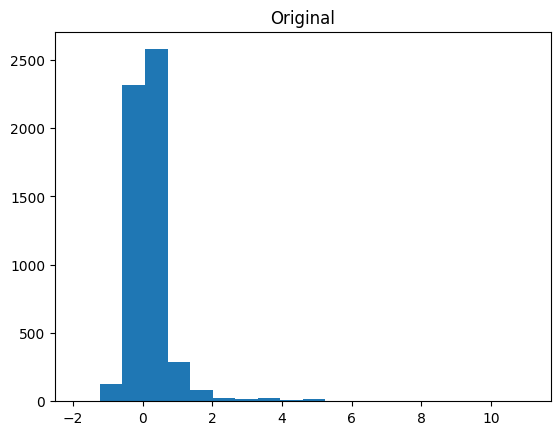

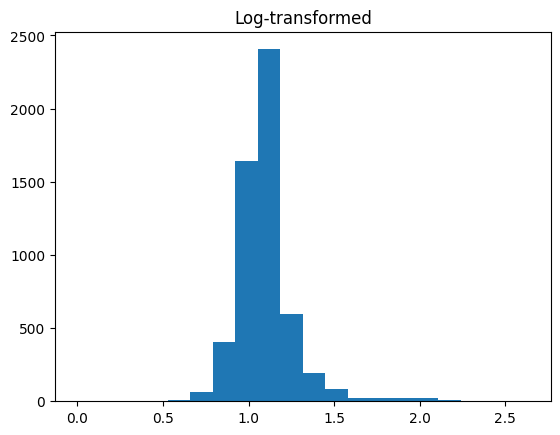

Applied log1p transform (shift=-1.869).


In [53]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")


# CROSS-VAL SPLITS

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.098–0.100


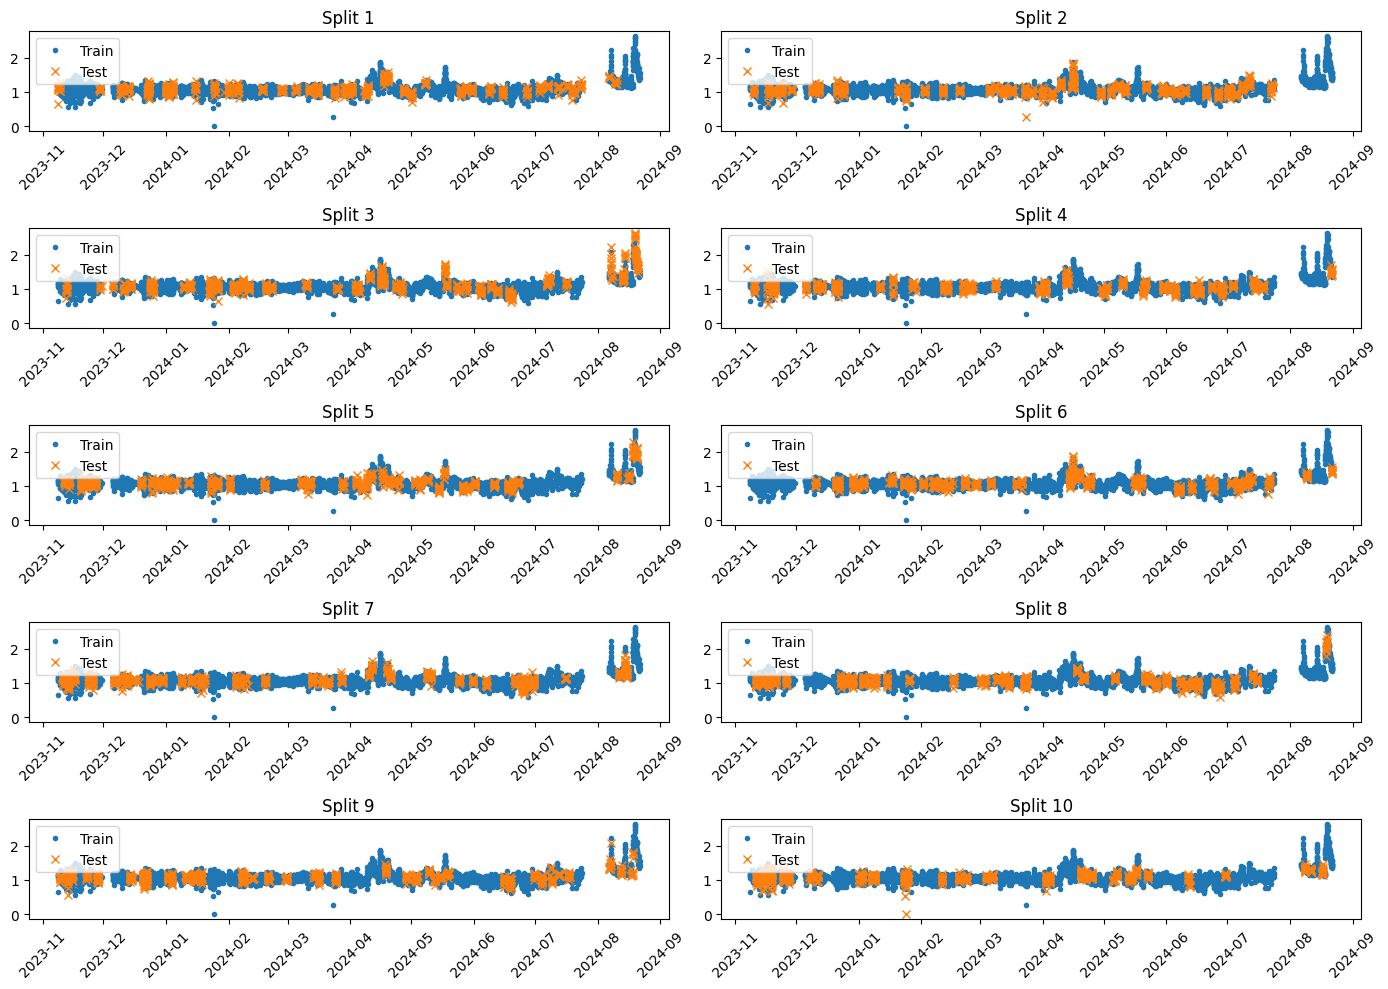

In [54]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# FEATURE SELECTION

In [55]:
# Model factory
def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    elif MODEL_TYPE == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("MODEL_TYPE must be 'RandomForest' or 'XGBoost'")

model_factory()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
best_feats, ranking, hist = rfe_selection(
    X, y, splits,
    model_factory=model_factory,
    inv_y=inv_fn if LOG_TRANSFORM else None,
    step=1,           # try 5 or 10 if it’s slow
    min_features=1,   # stop at 5 features if you want
    verbose=True,
    score_mode='composite',  # 'rmse' or 'composite',
    w_penalty = 0.001
)

# optional plot in notebook
hist.plot(x="n_features", y="rmse_oof");
hist.plot(x="n_features", y="r2_oof");

print(f"\nBest features selected:\n{best_feats}")
print(f"\nFeature ranking:\n{ranking}")


Iter 1: kept=212 removed=['timesince_harvest'] RMSE_oof=0.3921 R2_oof=0.7238
Iter 2: kept=211 removed=['timesince_fert_org'] RMSE_oof=0.3921 R2_oof=0.7238


# EXPORT 

In [ ]:
filename = f"best_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in best_feats:
        f.write(f"{item}\n")
print("Wrote:", filename)

filename = f"ranked_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in ranking:
        f.write(f"{item}\n")
print("Wrote:", filename)


Wrote: best_features_FN2O_XGBoost.txt
Wrote: ranked_features_FN2O_XGBoost.txt


# **End of notebook**

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-21 20:43:26
